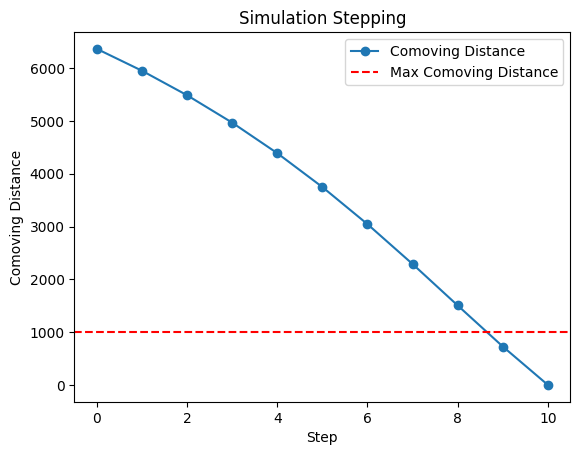

In [24]:
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt

import jax_fli as jfli

a_vals = jfli.simulation_stepping(
    jc.Planck18(), 0.1, 1.0, 10, nb_shells=None, max_comoving_distance=1000.0, time_stepping="log_a"
)

comoving_distances = jc.background.radial_comoving_distance(jc.Planck18(), a_vals)

plt.plot(jnp.arange(len(comoving_distances)), comoving_distances, marker="o", label="Comoving Distance")
plt.axhline(1000.0, color="red", linestyle="--", label="Max Comoving Distance")
plt.xlabel("Step")
plt.ylabel("Comoving Distance")
plt.title("Simulation Stepping")
plt.legend()
plt.show()

In [2]:
jfli.simulation_stepping?

Signature:
jfli.simulation_stepping(
    cosmo,
    t0,
    t1,
    n_steps,
    *,
    ts=None,
    nb_shells=None,
    max_comoving_distance=None,
    shell_spacing='comoving',
    min_width=50.0,
    density_widths=None,
    time_stepping='a',
)
Docstring:
Return the exact scale factors visited during integration.

Replicates the double-loop logic of ``integrate()``: the outer loop
iterates over shell targets (from ``ts``), the inner loop advances by
``dt_internal`` in the solver's time variable, clipping to each target.

When *nb_shells* and *max_comoving_distance* are provided, ``resolve_geometry``
is called internally to derive the shell scale factors.

Parameters
----------
cosmo : jax_cosmo.Cosmology
    Cosmology for distance/growth calculations.
t0 : float
    Initial scale factor.
t1 : float
    Final scale factor.
n_steps : int
    Number of integration steps from *t0* to *t1*.
ts : array-like, optional
    Shell target scale factors (descending). Mutually exclusive with
  

In [3]:
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt

import jax_fli as jfli
from jax_fli.fields.painting import PaintingOptions
from jax_fli.pm._resolve_geometry import resolve_ts_geometry

cosmo = jc.Planck15()
field = jfli.DensityField(
    array=jnp.zeros((128, 128, 128)),
    mesh_size=(128, 128, 128),
    box_size=(3000.0, 3000.0, 3000.0),
    unit=jfli.units.DENSITY,
)
PAINTING = PaintingOptions(target="spherical")

in_ts = jnp.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 1.0])

ts, r_centers, density_widths, nb_shells, nb_steps = resolve_ts_geometry(
    cosmo,
    field.max_comoving_radius,
    time_stepping="a",
    nb_shells=None,
    nb_steps=None,
    r_max_sim=9000,
    min_width=50.0,
    ts=in_ts,
    density_widths=None,
)

print(f"ts: {ts}")
print(f"r_centers: {r_centers}")
print(f"density_widths: {density_widths}")
print(f"nb_shells: {nb_shells}")
print(f"nb_steps: {nb_steps}")

ts: [0.01 0.02 0.05 0.1  0.2  0.5  1.  ]
r_centers: [8712.58403958 8265.73206166 7379.16305883 6380.46456579 4972.96879972
 2300.59580727    0.        ]
density_widths: [ 446.85197793  666.71049038  942.63374793 1203.09712956 2039.93437926
 2486.48439986 1150.29790364]
nb_shells: 7
nb_steps: None


In [9]:
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt

import jax_fli as jfli
from jax_fli.fields.painting import PaintingOptions
from jax_fli.pm._resolve_geometry import resolve_ts_geometry

cosmo = jc.Planck15()
field = jfli.DensityField(
    array=jnp.zeros((128, 128, 128)),
    mesh_size=(128, 128, 128),
    box_size=(6000.0, 6000.0, 6000.0),
    unit=jfli.units.DENSITY,
)


ts, r_centers, density_widths, nb_shells, nb_steps = resolve_ts_geometry(
    cosmo,
    field.max_comoving_radius,
    time_stepping="comoving",
    nb_shells=15,
    nb_steps=None,
    r_max_sim=9000,
    min_width=50.0,
    ts=None,
    density_widths=None,
)

print(f"ts: {ts}")
print(f"r_centers: {r_centers}")
print(f"density_widths: {density_widths}")
print(f"nb_shells: {nb_shells}")
print(f"nb_steps: {nb_steps}")

ts: [0.41710911 0.44350935 0.47113433 0.50008808 0.53050671 0.56252734
 0.59633887 0.63214219 0.67019069 0.71078632 0.75428038 0.80111085
 0.8518051  0.90699818 0.96748074]
r_centers: [2900. 2700. 2500. 2300. 2100. 1900. 1700. 1500. 1300. 1100.  900.  700.
  500.  300.  100.]
density_widths: [200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200. 200.
 200.]
nb_shells: 15
nb_steps: 45


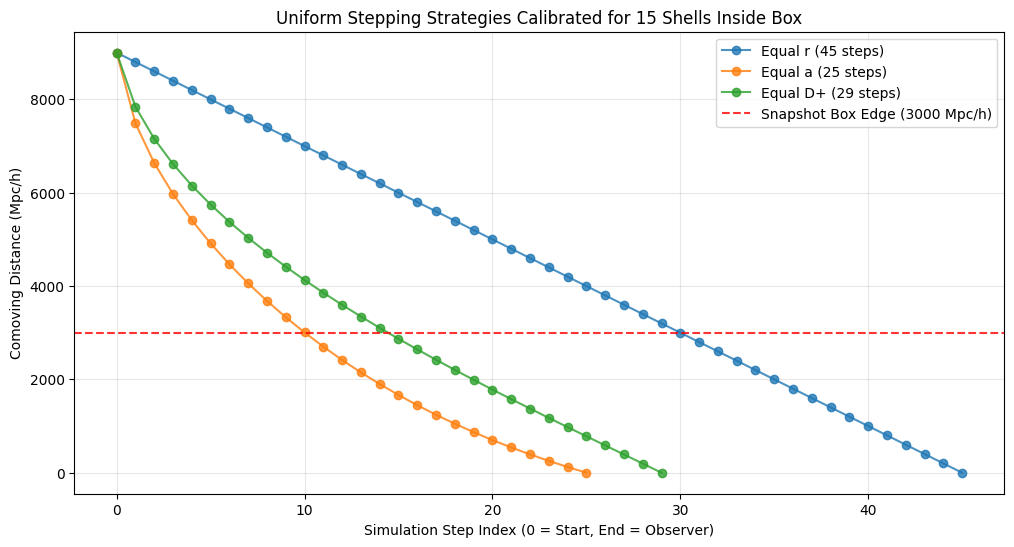

Target shells inside box: 15
------------------------------
Actual shells with Equal r:  16
Actual shells with Equal a:  15
Actual shells with Equal D+: 15
------------------------------
Total Integrator Steps (Equal r) : 45
Total Integrator Steps (Equal a) : 25
Total Integrator Steps (Equal D+): 29


In [6]:
import jax.numpy as jnp
import jax_cosmo as jc
import matplotlib.pyplot as plt
from jaxpm.growth import Dplus_to_a

# Import your custom growth functions
from jaxpm.growth import growth_factor as Gp

# --- Parameters ---
cosmo = jc.Planck18()

max_sim_comoving = 9000.0  # Outer edge of the entire simulation (e.g., z ~ 99)
max_box_comoving = 3000.0  # Outer edge of your snapshot lightcone box
total_shells = 15  # Number of exact snapshots you need INSIDE the box

# Calculate boundary scale factors and growth factors
a_ini = jc.background.a_of_chi(cosmo, max_sim_comoving).squeeze()
D_ini = Gp(cosmo, a_ini).squeeze()

a_box = jc.background.a_of_chi(cosmo, max_box_comoving).squeeze()
D_box = Gp(cosmo, a_box).squeeze()

D_today = Gp(cosmo, 1.0)

# ---------------------------------------------------------
# 1. Equal Comoving Distance (r) Strategy
# ---------------------------------------------------------
delta_r = max_box_comoving / total_shells
steps_outside_r = int((max_sim_comoving - max_box_comoving) / delta_r)
total_steps_r = total_shells + steps_outside_r

# Create perfectly uniform steps across the whole simulation
r_eq_r = jnp.linspace(max_sim_comoving, 0.0, total_steps_r + 1)


# ---------------------------------------------------------
# 2. Equal Scale Factor (a) Strategy
# ---------------------------------------------------------
delta_a = (1.0 - a_box) / total_shells
steps_outside_a = int((a_box - a_ini) / delta_a)
total_steps_a = total_shells + steps_outside_a

a_eq_a = jnp.linspace(a_ini, 1.0, total_steps_a + 1)
r_eq_a = jc.background.radial_comoving_distance(cosmo, a_eq_a)


# ---------------------------------------------------------
# 3. Equal Growth Factor (D+) Strategy (Recommended)
# ---------------------------------------------------------
delta_D = (D_today - D_box) / total_shells
steps_outside_D = int((D_box - D_ini) / delta_D)
total_steps_D = total_shells + steps_outside_D

D_eq_d = jnp.linspace(D_ini, D_today, total_steps_D + 1)
a_eq_d = Dplus_to_a(cosmo, D_eq_d)
r_eq_d = jc.background.radial_comoving_distance(cosmo, a_eq_d)


# ---------------------------------------------------------
# Plotting
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot each strategy. Note: They will have slightly different total step counts!
plt.plot(
    jnp.arange(total_steps_r + 1),
    r_eq_r,
    marker="o",
    linestyle="-",
    alpha=0.8,
    label=f"Equal r ({total_steps_r} steps)",
)
plt.plot(
    jnp.arange(total_steps_a + 1),
    r_eq_a,
    marker="o",
    linestyle="-",
    alpha=0.8,
    label=f"Equal a ({total_steps_a} steps)",
)
plt.plot(
    jnp.arange(total_steps_D + 1),
    r_eq_d,
    marker="o",
    linestyle="-",
    alpha=0.8,
    label=f"Equal D+ ({total_steps_D} steps)",
)

plt.axhline(max_box_comoving, color="red", linestyle="--", alpha=0.8, label="Snapshot Box Edge (3000 Mpc/h)")
plt.xlabel("Simulation Step Index (0 = Start, End = Observer)")
plt.ylabel("Comoving Distance (Mpc/h)")
plt.title(f"Uniform Stepping Strategies Calibrated for {total_shells} Shells Inside Box")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ---------------------------------------------------------
# Verification Printouts
# ---------------------------------------------------------
# Because we cast the outside steps to an integer and then run a uniform linspace,
# the number of shells strictly inside the box will be highly accurate, usually exactly the target.
print(f"Target shells inside box: {total_shells}")
print("-" * 30)
print(f"Actual shells with Equal r:  {jnp.sum(r_eq_r < max_box_comoving)}")
print(f"Actual shells with Equal a:  {jnp.sum(r_eq_a < max_box_comoving)}")
print(f"Actual shells with Equal D+: {jnp.sum(r_eq_d < max_box_comoving)}")
print("-" * 30)
print(f"Total Integrator Steps (Equal r) : {total_steps_r}")
print(f"Total Integrator Steps (Equal a) : {total_steps_a}")
print(f"Total Integrator Steps (Equal D+): {total_steps_D}")

In [51]:
print(f"number of shells with r_eq_a: {jnp.sum(r_eq_a < max_box_comoving)}")
print(f"number of shells with r_eq_d: {jnp.sum(r_eq_d < max_box_comoving)}")
print(f"number of shells with r_eq_r: {jnp.sum(r_eq_r < max_box_comoving)}")

number of shells with r_eq_a: 9
number of shells with r_eq_d: 8
number of shells with r_eq_r: 6


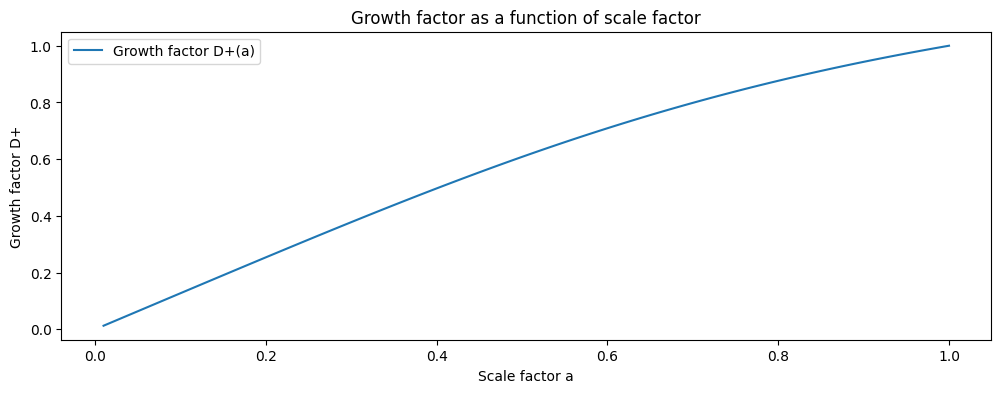

In [16]:
a = jnp.linspace(0.01, 1.0, 100)
g = Gp(cosmo, a)
plt.figure(figsize=(12, 4))
plt.plot(a, g, label="Growth factor D+(a)")
plt.xlabel("Scale factor a")
plt.ylabel("Growth factor D+")
plt.title("Growth factor as a function of scale factor")
plt.legend()
plt.show()